Accuracy:  0.44871794871794873
              precision    recall  f1-score   support

           0       0.44      0.52      0.47       100
           1       0.28      0.21      0.24        86
           2       0.55      0.56      0.55       126

    accuracy                           0.45       312
   macro avg       0.42      0.43      0.42       312
weighted avg       0.44      0.45      0.44       312



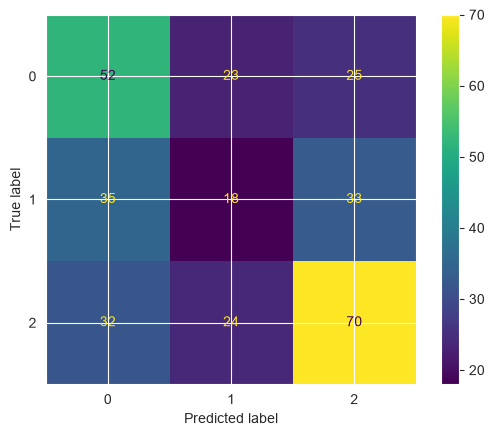

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay
)
import matplotlib as plt

df = pd.read_csv("../data/processed/epl_features.csv")
features = ["HomeGoalsAvg", "AwayGoalsAvg", "HomeShotsOnTargetAvg", "AwayShotsOnTargetAvg", "HomeCornersAvg", "AwayCornersAvg", "HomeFoulsAvg", "AwayFoulsAvg"]
X = df[features]
y = df["FTR"]
encoder = LabelEncoder()
y = encoder.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, predictions)